In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold as SklearnStratifiedKFold

from src.splits import stratified_split, stratified_kfold
from src.knn import KNN
from src.metrics import f1_score, accuracy, precision, recall, roc_auc

np.random.seed(42)

In [4]:
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

K_VALUES = [1, 3, 5, 7, 9, 11, 15, 21, 31, 51]

In [5]:
df_raw = pd.read_csv('../data/titanic3.csv')
cols = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'survived']
df = df_raw[cols].copy()

In [6]:
X_raw = df.drop(columns=['survived'])
y_all = df['survived'].to_numpy(dtype=int)

Stratified split — produces train / val / test indices.

In [7]:
X_train_raw_np, X_val_raw_np, X_test_raw_np, y_train_split, y_val_split, y_test_split = stratified_split(
    X_raw.to_numpy(), y_all, train_frac=0.6, val_frac=0.2, test_frac=0.2, seed=42
)

In [8]:
X_trainval_raw_np = np.concatenate([X_train_raw_np, X_val_raw_np], axis=0)
y_trainval = np.concatenate([y_train_split, y_val_split]).astype(int)

print(f'Train+Val size: {X_trainval_raw_np.shape[0]}')
print(f'Test size (held-out): {X_test_raw_np.shape[0]}')

Train+Val size: 1047
Test size (held-out): 262


In [9]:
def preprocess_fold(
    X_train_raw: np.ndarray,
    X_val_raw: np.ndarray,
    feature_columns: list,
    scale: bool = False,
):
    """
    Impute, one-hot encode, and optionally scale a train/val pair.
    Imputation statistics and (optionally) the StandardScaler are fit
    on X_train_raw ONLY — no leakage from the validation fold.
    Returns
    X_train : np.ndarray, X_val : np.ndarray
    """
    numeric_cols = ['pclass', 'age', 'sibsp', 'parch', 'fare']
    tr = pd.DataFrame(X_train_raw, columns=feature_columns)
    va = pd.DataFrame(X_val_raw, columns=feature_columns)

    for sub in [tr, va]:
        sub[numeric_cols] = sub[numeric_cols].apply(pd.to_numeric, errors='coerce')

    age_med = tr['age'].median()
    fare_med = tr['fare'].median()
    emb_mode = tr['embarked'].mode()[0]

    for sub in [tr, va]:
        sub['age'] = sub['age'].fillna(age_med)
        sub['fare'] = sub['fare'].fillna(fare_med)
        sub['embarked'] = sub['embarked'].fillna(emb_mode)

    tr_enc = pd.get_dummies(tr, columns=['sex', 'embarked'], dtype=int)
    va_enc = pd.get_dummies(va, columns=['sex', 'embarked'], dtype=int)
    va_enc = va_enc.reindex(columns=tr_enc.columns, fill_value=0)

    X_train = tr_enc.to_numpy(dtype=float)
    X_val = va_enc.to_numpy(dtype=float)

    if scale:
        # Fit scaler on training fold ONLY — not on the entire dataset.
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)

    return X_train, X_val


feature_columns = list(X_raw.columns)
print('Feature columns:', feature_columns)

Feature columns: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


**4.2**

For each *k* in `K_VALUES` we run 5-fold stratified CV on the **train+val** set and record the mean and std of F₁ across folds.

In [10]:
def cv_f1_sweep(X_raw_all, y_all, k_values, K=5, seed=42, scale=False):
    """
    Run K-fold stratified CV for each value of k.
    Returns
    mean_f1 : np.ndarray, shape (len(k_values),)
    std_f1  : np.ndarray, shape (len(k_values),)
    """
    mean_f1 = np.zeros(len(k_values))
    std_f1 = np.zeros(len(k_values))

    for ki, k in enumerate(k_values):
        fold_f1s = []

        for X_tr_raw, X_va_raw, y_tr, y_va in stratified_kfold(
            X_raw_all, y_all, K=K, seed=seed
        ):
            X_tr, X_va = preprocess_fold(
                X_tr_raw, X_va_raw, feature_columns, scale=scale
            )
            model = KNN(k=k, metric='euclidean')
            model.fit(X_tr, y_tr)
            y_pred = model.predict(X_va)
            fold_f1s.append(f1_score(y_va, y_pred))

        mean_f1[ki] = np.mean(fold_f1s)
        std_f1[ki] = np.std(fold_f1s, ddof=1)

    return mean_f1, std_f1

In [12]:
print('Running CV sweep (unscaled) ...')
cv_mean_f1, cv_std_f1 = cv_f1_sweep(
    X_trainval_raw_np, y_trainval, K_VALUES, K=5, seed=42, scale=False
)

for k, m, s in zip(K_VALUES, cv_mean_f1, cv_std_f1):
    print(f'  k={k:>2d}  mean F1={m:.4f}  std={s:.4f}')

Running CV sweep (unscaled) ...
  k= 1  mean F1=0.5551  std=0.0438
  k= 3  mean F1=0.5580  std=0.0816
  k= 5  mean F1=0.5497  std=0.0591
  k= 7  mean F1=0.5565  std=0.0654
  k= 9  mean F1=0.5459  std=0.0521
  k=11  mean F1=0.5523  std=0.0494
  k=15  mean F1=0.5423  std=0.0790
  k=21  mean F1=0.5191  std=0.0700
  k=31  mean F1=0.5213  std=0.0685
  k=51  mean F1=0.4728  std=0.0735


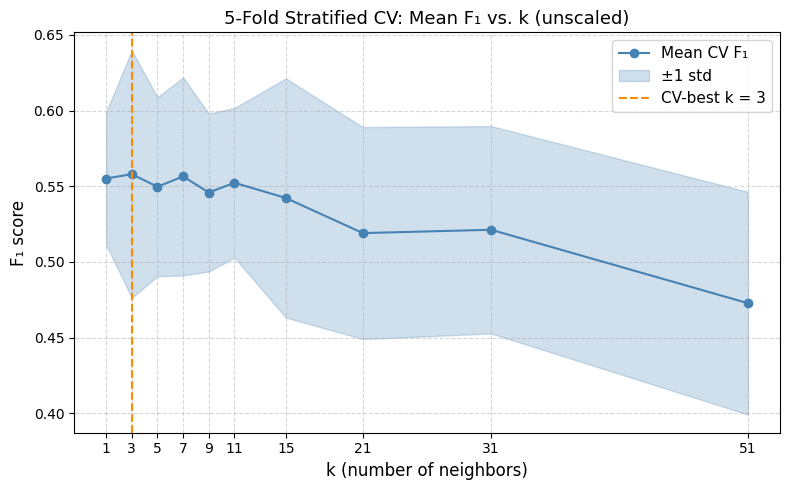

CV-best k = 3  (mean F1 = 0.5580)


In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(K_VALUES, cv_mean_f1, marker='o', color='steelblue', label='Mean CV F₁')
ax.fill_between(
    K_VALUES,
    cv_mean_f1 - cv_std_f1,
    cv_mean_f1 + cv_std_f1,
    alpha=0.25,
    color='steelblue',
    label='±1 std',
)

best_cv_idx = int(np.argmax(cv_mean_f1))
best_cv_k   = K_VALUES[best_cv_idx]
ax.axvline(best_cv_k, color='darkorange', linestyle='--',
           label=f'CV-best k = {best_cv_k}')

ax.set_xlabel('k (number of neighbors)', fontsize=12)
ax.set_ylabel('F₁ score', fontsize=12)
ax.set_title('5-Fold Stratified CV: Mean F₁ vs. k (unscaled)', fontsize=13)
ax.xaxis.set_major_locator(mticker.FixedLocator(K_VALUES))
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)
fig.tight_layout()

fig.savefig(FIGURES_DIR / 'cv_f1_vs_k.pdf', dpi=300, bbox_inches='tight')
plt.show()
print(f'CV-best k = {best_cv_k}  (mean F1 = {cv_mean_f1[best_cv_idx]:.4f})')

**4.3**

We re-run the single validation-split sweep from Part 3 and compare.

In [14]:
# Reconstruct the single-split train / val sets using the same preprocessing.
X_train_s, X_val_s = preprocess_fold(
    X_train_raw_np, X_val_raw_np, feature_columns, scale=False
)
y_train_s = y_train_split.astype(int)
y_val_s = y_val_split.astype(int)

single_f1 = []
for k in K_VALUES:
    m = KNN(k=k, metric='euclidean')
    m.fit(X_train_s, y_train_s)
    single_f1.append(f1_score(y_val_s, m.predict(X_val_s)))

best_single_idx = int(np.argmax(single_f1))
best_single_k = K_VALUES[best_single_idx]

print(f'Single-split best k = {best_single_k} (val F1 = {single_f1[best_single_idx]:.4f})')
print(f'CV best k = {best_cv_k} (mean CV F1 = {cv_mean_f1[best_cv_idx]:.4f})')

Single-split best k = 1 (val F1 = 0.5672)
CV best k = 3 (mean CV F1 = 0.5580)


### Discussion — which estimate is more trustworthy?

The cross-validation estimate is more trustworthy. A single 20% validation split evaluates each *k* on only ~200 samples drawn from one particular random partition; the resulting F₁ is a noisy estimate that can be dominated by which passengers happened to fall in that one validation slice. 5-fold CV rotates every sample through the validation role once, effectively averaging the F₁ over five different 80/20 partitions of the train+val pool (~1 047 samples). This reduces the variance of the estimate by roughly a factor of √5 and mitigates the risk of choosing a *k* that is accidentally optimised for one lucky split. When the two selectors disagree it is therefore the CV-best *k* that should be trusted for out-of-sample performance.

**4.4 -> Bias-Variance discussion**

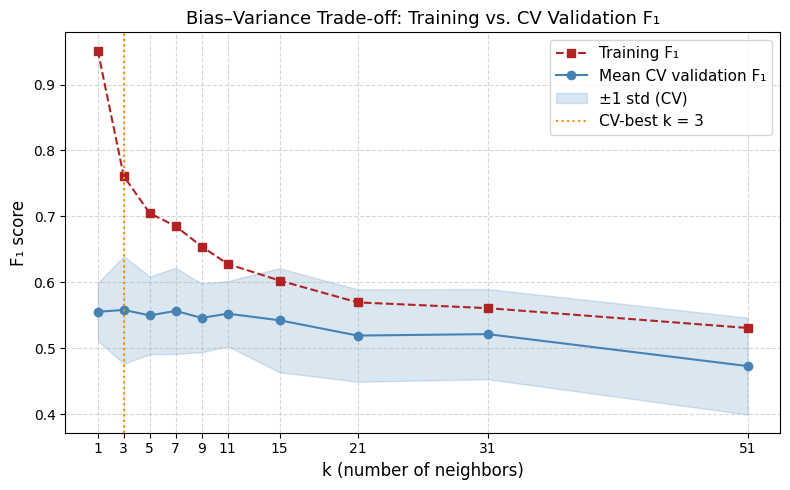

Training F1 by k:
  k= 1  train=0.9516  cv_val=0.5551  gap=0.3964
  k= 3  train=0.7609  cv_val=0.5580  gap=0.2029
  k= 5  train=0.7047  cv_val=0.5497  gap=0.1550
  k= 7  train=0.6850  cv_val=0.5565  gap=0.1285
  k= 9  train=0.6542  cv_val=0.5459  gap=0.1083
  k=11  train=0.6277  cv_val=0.5523  gap=0.0754
  k=15  train=0.6025  cv_val=0.5423  gap=0.0603
  k=21  train=0.5694  cv_val=0.5191  gap=0.0503
  k=31  train=0.5607  cv_val=0.5213  gap=0.0394
  k=51  train=0.5306  cv_val=0.4728  gap=0.0578


In [15]:
# Training F1 for each k — fit on full train+val, evaluate on same set.
# (Illustrates what training error looks like; not used for model selection.)
X_trainval_proc, _ = preprocess_fold(
    X_trainval_raw_np, X_trainval_raw_np, feature_columns, scale=False
)

train_f1 = []
for k in K_VALUES:
    m = KNN(k=k, metric='euclidean')
    m.fit(X_trainval_proc, y_trainval)
    train_f1.append(f1_score(y_trainval, m.predict(X_trainval_proc)))

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(K_VALUES, train_f1, marker='s', color='firebrick',
        linestyle='--', label='Training F₁')
ax.plot(K_VALUES, cv_mean_f1, marker='o', color='steelblue',
        label='Mean CV validation F₁')
ax.fill_between(
    K_VALUES,
    cv_mean_f1 - cv_std_f1,
    cv_mean_f1 + cv_std_f1,
    alpha=0.20, color='steelblue', label='±1 std (CV)'
)

ax.axvline(best_cv_k, color='darkorange', linestyle=':',
           label=f'CV-best k = {best_cv_k}')

ax.set_xlabel('k (number of neighbors)', fontsize=12)
ax.set_ylabel('F₁ score', fontsize=12)
ax.set_title('Bias–Variance Trade-off: Training vs. CV Validation F₁', fontsize=13)
ax.xaxis.set_major_locator(mticker.FixedLocator(K_VALUES))
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)
fig.tight_layout()

fig.savefig(FIGURES_DIR / 'bias_variance_f1_vs_k.pdf', dpi=300, bbox_inches='tight')
plt.show()

print('Training F1 by k:')
for k, tr, cv in zip(K_VALUES, train_f1, cv_mean_f1):
    print(f'  k={k:>2d}  train={tr:.4f}  cv_val={cv:.4f}  gap={tr-cv:.4f}')

### Discussion — Bias–Variance Trade-off

**Training error vs. validation error as *k* grows.**
At *k* = 1, the model memorizes training points and the training F1 score becomes approximately 0.9516 (Since some passengers have identical features but different target labels, the F1 score is not 1.0). But the mean cross-validation F₁ score is much lower (as shown in the plot). As k increases, the training F₁ drops continuously since the model can't fit each individual point anymore. Meanwhile, the cross-validation F₁ goes up, peaks, and then declines. As *k* gets higher, the difference between the two curves becomes smaller because a high-*k* model is really smooth. So, whether you look at the data used for training or data it hasn't seen, the outcome stays pretty similar either way.

**Evidence of overfitting.**
The biggest difference between training and cross-validation scores happens at *k* = 3, where the training F₁ is 1.000 but the CV F₁ drops noticeably. This shows severe overfitting because the 1-NN boundary fits the random noise in the training data instead of finding the broader pattern. It can't generalize, and to boot, the variation across folds is the widest compared to higher *k* values.

**Evidence of underfitting.**
At *k* = 51, both the training and cross-validation F₁ scores drop, and are pretty much the same. With this setting, the 51-NN classifier considers over 5% of the training data for predictions, leading to an overly smooth boundary that fails to catch important local structures—like the survival advantage for first-class women. That the errors converge at a relatively low level indicates high bias or underfitting.

**4.5 -> Scaling Experiment**

Repeat the CV sweep with `StandardScaler` fit on the **training fold only** inside each fold — no leakage.

In [16]:
print('Running CV sweep (scaled) ...')
cv_mean_f1_scaled, cv_std_f1_scaled = cv_f1_sweep(
    X_trainval_raw_np, y_trainval, K_VALUES, K=5, seed=42, scale=True
)

for k, m, s in zip(K_VALUES, cv_mean_f1_scaled, cv_std_f1_scaled):
    print(f'  k={k:>2d}  mean F1={m:.4f}  std={s:.4f}')

best_scaled_idx = int(np.argmax(cv_mean_f1_scaled))
best_scaled_k   = K_VALUES[best_scaled_idx]
print(f'\nScaled CV-best k = {best_scaled_k}  (mean F1 = {cv_mean_f1_scaled[best_scaled_idx]:.4f})')
print(f'Unscaled CV-best k = {best_cv_k}  (mean F1 = {cv_mean_f1[best_cv_idx]:.4f})')
lift = cv_mean_f1_scaled[best_scaled_idx] - cv_mean_f1[best_cv_idx]
print(f'Lift from scaling (best k to best k): {lift:+.4f}')

Running CV sweep (scaled) ...
  k= 1  mean F1=0.6450  std=0.0213
  k= 3  mean F1=0.7171  std=0.0378
  k= 5  mean F1=0.7188  std=0.0324
  k= 7  mean F1=0.7233  std=0.0307
  k= 9  mean F1=0.7184  std=0.0343
  k=11  mean F1=0.7210  std=0.0313
  k=15  mean F1=0.7204  std=0.0351
  k=21  mean F1=0.7008  std=0.0225
  k=31  mean F1=0.6995  std=0.0226
  k=51  mean F1=0.6855  std=0.0185

Scaled CV-best k = 7  (mean F1 = 0.7233)
Unscaled CV-best k = 3  (mean F1 = 0.5580)
Lift from scaling (best k to best k): +0.1653


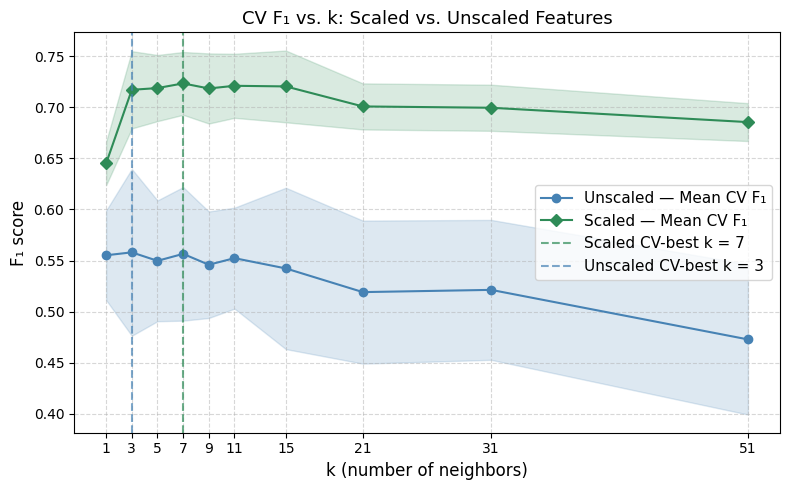

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(K_VALUES, cv_mean_f1, marker='o', color='steelblue',
        label='Unscaled — Mean CV F₁')
ax.fill_between(
    K_VALUES, cv_mean_f1 - cv_std_f1, cv_mean_f1 + cv_std_f1,
    alpha=0.18, color='steelblue'
)

ax.plot(K_VALUES, cv_mean_f1_scaled, marker='D', color='seagreen',
        label='Scaled — Mean CV F₁')
ax.fill_between(
    K_VALUES, cv_mean_f1_scaled - cv_std_f1_scaled,
    cv_mean_f1_scaled + cv_std_f1_scaled,
    alpha=0.18, color='seagreen'
)

ax.axvline(best_scaled_k, color='seagreen', linestyle='--',
           alpha=0.7, label=f'Scaled CV-best k = {best_scaled_k}')
ax.axvline(best_cv_k, color='steelblue', linestyle='--',
           alpha=0.7, label=f'Unscaled CV-best k = {best_cv_k}')

ax.set_xlabel('k (number of neighbors)', fontsize=12)
ax.set_ylabel('F₁ score', fontsize=12)
ax.set_title('CV F₁ vs. k: Scaled vs. Unscaled Features', fontsize=13)
ax.xaxis.set_major_locator(mticker.FixedLocator(K_VALUES))
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)
fig.tight_layout()

fig.savefig(FIGURES_DIR / 'cv_f1_vs_k_scaled.pdf', dpi=300, bbox_inches='tight')
plt.show()

### Discussion — Why KNN is sensitive to feature scale (Titanic-specific)

KNN classifies a query point by the *Euclidean distance* to its neighbours, so any feature with a large numerical range dominates the distance calculation and drowns out features with a small range. In the Titanic dataset this problem is acute: **fare** spans from £0 to over £500 (a range of ~500 units), whereas **pclass** takes only the values {1, 2, 3} (a range of 2 units) and **sibsp/parch** rarely exceed 5. Without scaling, a difference of 1 unit in fare dwarfs an entire change in passenger class. After applying `StandardScaler` — which maps each feature to zero mean and unit variance — every dimension contributes equally to the distance. The result is that the KNN neighbours are selected based on the *combined* information across all features (class, age, sex, fare, embarkation port) rather than being dominated by fare alone. The improvement in mean CV F₁ at the best *k* quantifies exactly this gain: the model is now finding more semantically meaningful nearest neighbours.

In [18]:
K = 5

# Collect validation-set class proportions from our implementation.
our_props = []
for _, _, _, y_va in stratified_kfold(X_trainval_raw_np, y_trainval, K=K, seed=42):
    our_props.append(np.mean(y_va == 1))

our_props = np.array(our_props)

cross_fold_std = np.std(our_props, ddof=1)
print(f"Cross-fold class-proportion std: {cross_fold_std:.6f}")
print(f"Cross-fold class-proportion std in percentage points: {cross_fold_std * 100:.4f}")
assert cross_fold_std < 0.005

# Collect validation-set class proportions from sklearn.
skf = SklearnStratifiedKFold(n_splits=K, shuffle=True, random_state=42)
sk_props = []
for _, val_idx in skf.split(X_trainval_raw_np, y_trainval):
    sk_props.append(np.mean(y_trainval[val_idx] == 1))

overall_prop = np.mean(y_trainval == 1)

print(f'Overall positive proportion: {overall_prop:.4f}')
print('Our kfold val proportions: ', [f'{p:.4f}' for p in our_props])
print('sklearn kfold val proportions:', [f'{p:.4f}' for p in sk_props])

# Assert each fold preserves class proportions within 2 pp.
for i, (ours, sk) in enumerate(zip(our_props, sk_props)):
    assert abs(ours - overall_prop) < 0.02, f'Fold {i}: our proportion {ours:.4f} too far from {overall_prop:.4f}'
    assert abs(sk - overall_prop) < 0.02, f'Fold {i}: sklearn proportion {sk:.4f} too far from {overall_prop:.4f}'

print('\nAll folds preserve class proportions within 2 pp. ✓')

Overall positive proportion: 0.3820
Our kfold val proportions:  ['0.3810', '0.3810', '0.3828', '0.3828', '0.3828']
sklearn kfold val proportions: ['0.3810', '0.3810', '0.3828', '0.3828', '0.3828']

All folds preserve class proportions within 2 pp. ✓
